In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import math
import pandas as pd
import os
from scipy.interpolate import interp1d, splrep, splev
import random
import csv


# Folder containing the CSV files

    
def adjust_the_line(red_cell, green_cell):

    # Red
    new_red_value = interplote_data(red_cell, 1000)

    average = lowess_smooth(new_red_value)

    baseline_average = find_baseline(average)
    mini_crop, max_crop = find_crops(average, baseline_average)
    data_new = average[mini_crop: max_crop]
    # Perform interpolation
    x = np.linspace(0,1, len(data_new))
    y = data_new
    spl = splrep(x, y)  # Fit the spline
    new_x = np.linspace(x.min(), x.max(), 1000)  
    new_red_y = splev(new_x, spl) 

    # Green
    new_green_value = interplote_data(green_cell, 1000)
    
    smooth_green = lowess_smooth(new_green_value)
    data_new_green = smooth_green[mini_crop: max_crop]
    # Perform interpolation
    x = np.linspace(0,1, len(data_new_green))
    y = data_new_green
    spl = splrep(x, y)  # Fit the spline
    new_x = np.linspace(x.min(), x.max(), 1000)  
    new_green_y = splev(new_x, spl) 

    
    return new_red_y,new_green_y



def interplote_data(list, num):
    x = np.linspace(0,1, len(list))
    spl = splrep(x, list)
    new_x = np.linspace(0,1, num)
    new_value = splev(new_x, spl)
    return new_value


        
def find_baseline(data):
    n = len(data)

    start_index = int(n * 0.30)
    end_index = int(n * 0.70)
    middle_40_percent = data[start_index:end_index]
    min_value = min(middle_40_percent)
    min_indices_relative = [i for i, value in enumerate(middle_40_percent) if value == min_value]
    min_indices_absolute = start_index + min_indices_relative[0]

    baseline_value = data[min_indices_absolute-int(n*0.005):min_indices_absolute+int(n*0.005)]
    baseline_average = np.mean(baseline_value)
    return baseline_average


def find_crops(data, target_value):
    data_as_int = [int(float(x)) for x in data]
    matching_indices = [i for i, value in enumerate(data_as_int) if value<target_value]
    mini_crop = 0
    max_crop = len(data)
    if 0 in matching_indices:
        i = 0
        while i in range(0,len(matching_indices)):
            if 0<(matching_indices[i+1]-matching_indices[i]) <=2:
                mini_crop = matching_indices[i+1] 
                i += 1
            else:
                break

    reverse_matching_indices = matching_indices[::-1]

    if (len(data)-1) in reverse_matching_indices:
        i = 0
        while i in range(0,len(reverse_matching_indices)):
            if 0<(reverse_matching_indices[i]-reverse_matching_indices[i+1]) <=2:
                max_crop = reverse_matching_indices[i+1] 
                i += 1
            else:
                break

    return mini_crop, max_crop


def normalize_data(list):
    list_max = max(list)
    normalized_data_1d = [ (data / list_max)for data in list]
    return normalized_data_1d
    

def lowess_smooth (data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05 # IMPORTANT window length
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:,1]

def normalize_data(list):
    list_max = max(list)
    normalized_data_1d = [ (data / list_max)for data in list]
    return normalized_data_1d

def interpolate_data_b(x, y, num):
    spl = splrep(x, y)  
    new_x = np.linspace(min(x), max(x), num)  
    new_value = splev(new_x, spl)
    return new_value

def half_data (list, num):
    num_r = math.ceil(num/2)
    front_half = list[:num_r]
    back_half = list[num_r:]
    front_half_reversed = front_half[::-1]
    
    return front_half_reversed,back_half

def ave_center_data(data):
    n = len(data)

    start = int(n * 0.495)
    end = int(n * 0.595)
    middle_1_percent = data[start:end]

    baseline = sum(middle_1_percent) / len(middle_1_percent) 
    
    return baseline
    

def fraction (list):
    total_sum = sum(list)
    cumulative_sum = []
    current_sum = 0
    for value in list:
        current_sum += value
        cumulative_sum.append(current_sum)
    cumulative_weights = [(cs / total_sum)for cs in cumulative_sum]
    return cumulative_weights

# For 4th figure

def fig_4_create (new_red,new_green):
    
    # Green
    front_green,back_green = half_data (new_green, len(new_green))

    x_front = fraction (front_green)

    x_back = fraction (back_green)

    # Red

    baseline = ave_center_data (new_red)
    front_red,back_red = half_data (new_red, len(new_red))

    front_red_b = [(x/baseline) - 1 for x in front_red]
    back_red_b = [(x/baseline) - 1 for x in back_red]

    intensity_front = interpolate_data_b(x_front, front_red_b, 1000)
    intensity_back = interpolate_data_b(x_back, back_red_b, 1000)

    return intensity_front, intensity_back


def calculate_plot_parameter(intensities):
    average = np.mean(intensities, axis=0)
    average = lowess_smooth(average)

    stderr = np.std(intensities, axis=0) / np.sqrt(len(intensities))
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std


def figure_3_create(new_red,new_green):
    # Green
    front_green,back_green = half_data (new_green, len(new_green))
    x_front = fraction (front_green)
    x_back = fraction (back_green)

    # Red
    front_red,back_red = half_data (new_red, len(new_red))

    #Integrate
    intensity_front = interpolate_data_b (x_front, front_red, 1000)
    intensity_front = normalize_data(intensity_front)

    intensity_back = interpolate_data_b (x_back, back_red, 1000)
    intensity_back = normalize_data(intensity_back)

    return intensity_front, intensity_back



def readout_stat_para(csv_file):
    average_values = []
    stderr_values = []
    with open(csv_file, mode='r') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            average_values.append(float(row['average']))
            stderr_values.append(float(row['stderr']))
            
    average_values = np.array(average_values)
    stderr_values = np.array(stderr_values)

    return average_values, stderr_values



def negative_value(list):
    new_list  = [-(i) for i in list]
    return new_list

def allinfunction(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    total_lengths = []
    
    for file in csv_files: # range(0,len(df['Red_intensity']))
        df = pd.read_csv(os.path.join(folder_path, file))
        red_cell = df.iloc[:, 2].tolist() 
        total_lengths.append(len(red_cell))

    return total_lengths



def allinfunction(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    total_lengths = []
    
    for file in csv_files: # range(0,len(df['Red_intensity']))
        df = pd.read_csv(os.path.join(folder_path, file))
        distance = df.iloc[-1, 0]
        total_lengths.append(distance)

    return total_lengths



def allinfunction(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]


    red_values_list = []
    green_values_list = []
    fig_3_intensities = []
    fig_4_intensities = []
    total_lengths = []

    for file in csv_files: # range(0,len(df['Red_intensity']))
        try:
            df = pd.read_csv(os.path.join(folder_path, file))
            red_cell = df.iloc[:, 2].tolist() 
            green_cell = df.iloc[:, 1].tolist() 
            # new_red,new_green = adjust_the_line (red_cell, green_cell)
            new_green, new_red = adjust_the_line (green_cell, red_cell)

            # This is figure 1 & 2 parts
            normalized_red_value = normalize_data(new_red)
            normalized_green_value = normalize_data(new_green)
            red_values_list.append(normalized_red_value)
            green_values_list.append(normalized_green_value)

            # This is figure 3 part
            intensity_front_3, intensity_back_3 = figure_3_create(new_red,new_green)
            fig_3_intensities.append(intensity_front_3)
            fig_3_intensities.append(intensity_back_3)

            # This is figure 4 part
            intensity_front_4, intensity_back_4 = fig_4_create (new_red,new_green)
            averaged_list = [(a + b) / 2 for a, b in zip(intensity_front_4, intensity_back_4)]
            fig_4_intensities.append(averaged_list)

            # this is the only thing I want
            distance = df.iloc[-1, 0]
            total_lengths.append(distance)

        except:
            continue

    return total_lengths

# plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def mannwhitney_bar_with_dots(
    list1,
    list2,
    labels=("Control", "Drug"),
    ylabel="Value",
    figsize=(2.0, 3.0),
    bar_width=0.32,
    xpos=(0, 0.58),   
    ylim=(0, 50),
    bracket_height=2,
    bracket_offset=2,
    dot_size=14,
    jitter_strength=0.045,
):
    x1 = np.asarray(list1, dtype=float)
    x2 = np.asarray(list2, dtype=float)

    x1 = x1[np.isfinite(x1)]
    x2 = x2[np.isfinite(x2)]

    stat, p = mannwhitneyu(x1, x2, alternative="two-sided")

    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4g}")

    means = [np.mean(x1), np.mean(x2)]
    sems = [
        np.std(x1, ddof=1) / np.sqrt(len(x1)),
        np.std(x2, ddof=1) / np.sqrt(len(x2))
    ]

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    bar_colors = ["lightgray", "#FF9896"]

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=3,
        color=bar_colors,
        edgecolor="black",
        linewidth=1,
        width=bar_width,
        zorder=1
    )

    rng = np.random.default_rng(1)
    jitter1 = rng.normal(0, jitter_strength, size=len(x1))
    jitter2 = rng.normal(0, jitter_strength, size=len(x2))

    ax.scatter(
        np.full(len(x1), xpos[0]) + jitter1,
        x1,
        s=dot_size,
        color="black",
        alpha=0.65,
        edgecolors="none",
        zorder=2
    )

    ax.scatter(
        np.full(len(x2), xpos[1]) + jitter2,
        x2,
        s=dot_size,
        color="black",
        alpha=0.65,
        edgecolors="none",
        zorder=2
    )

    if p < 0.001:
        p_text = "***"
    elif p < 0.01:
        p_text = "**"
    elif p < 0.05:
        p_text = "*"
    else:
        p_text = "ns"

    y_max_data = max(
        np.max(x1),
        np.max(x2),
        means[0] + sems[0],
        means[1] + sems[1]
    )

    y = y_max_data + bracket_offset
    h = bracket_height

    ax.plot(
        [xpos[0], xpos[0], xpos[1], xpos[1]],
        [y, y + h, y + h, y],
        color="black",
        linewidth=1
    )

    ax.text(
        np.mean(xpos),
        y + h + 0.8,
        f"{p_text}, p = {p:.3g}",
        ha="center",
        va="bottom",
        fontsize=11
    )

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=9)

    ax.set_ylim(ylim)
    ax.set_xlim(xpos[0] - 0.35, xpos[1] + 0.35)

    plt.tight_layout()
    plt.show()

    return stat, p

## control

In [ ]:

file_path = r"timed fixation Fig3\t1 control" 
control_length1 = allinfunction(file_path)


file_path = r"timed fixation Fig3\t2 control" 

control_length2 = allinfunction(file_path)



file_path = r"timed fixation Fig3\t3 control" 

control_length3 = allinfunction(file_path)



file_path = r"timed fixation Fig3\t4 control" 

control_length4 = allinfunction(file_path)


file_path = r"timed fixation Fig3\t5 control" 
control_length5 = allinfunction(file_path)



file_path = r"timed fixation Fig3\t6 control" 

control_length6 = allinfunction(file_path)


file_path = r"timed fixation Fig3\t7 control" 

control_length7 = allinfunction(file_path)



file_path = r"timed fixation Fig3\t8 control" 

control_length8 = allinfunction(file_path)


control_lengths = [control_length1, control_length2, control_length3, control_length4, control_length5, control_length6, control_length7, control_length8]

## drug

In [ ]:
file_path = r"timed fixation Fig3\t1 drug" 
drug_length1 = allinfunction(file_path)



file_path = r"timed fixation Fig3\t2 drug" 

drug_length2 = allinfunction(file_path)


file_path = r"timed fixation Fig3\t3 drug" 

drug_length3 = allinfunction(file_path)


file_path = r"timed fixation Fig3\t4 drug" 

drug_length4 = allinfunction(file_path)



file_path = r"timed fixation Fig3\t5 drug" 

drug_length5 = allinfunction(file_path)


file_path = r"timed fixation Fig3\t6 drug" 

drug_length6 = allinfunction(file_path)



file_path = r"timed fixation Fig3\t7 drug" 

drug_length7 = allinfunction(file_path)


file_path = r"timed fixation Fig3\t8 drug" 

drug_length8 = allinfunction(file_path)


drug_lengths = [drug_length1, drug_length2, drug_length3, drug_length4, drug_length5, drug_length6, drug_length7, drug_length8]

# Figure S4B

Mann–Whitney U statistic = 257.000
p value = 0.5528


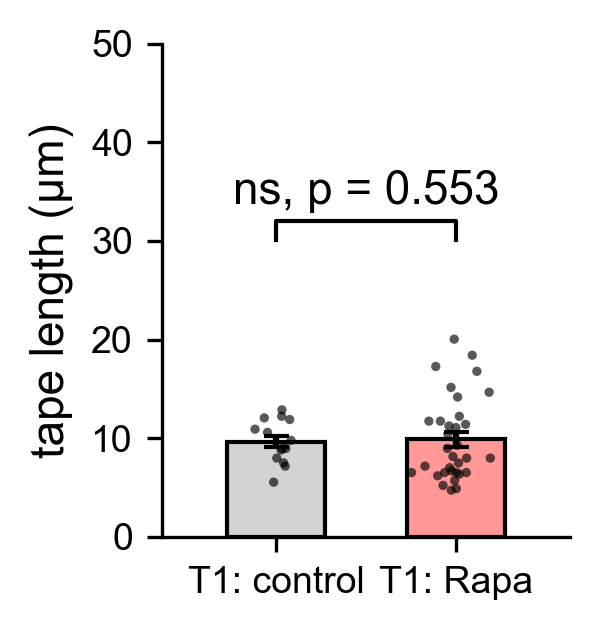

Mann–Whitney U statistic = 120.500
p value = 0.8582


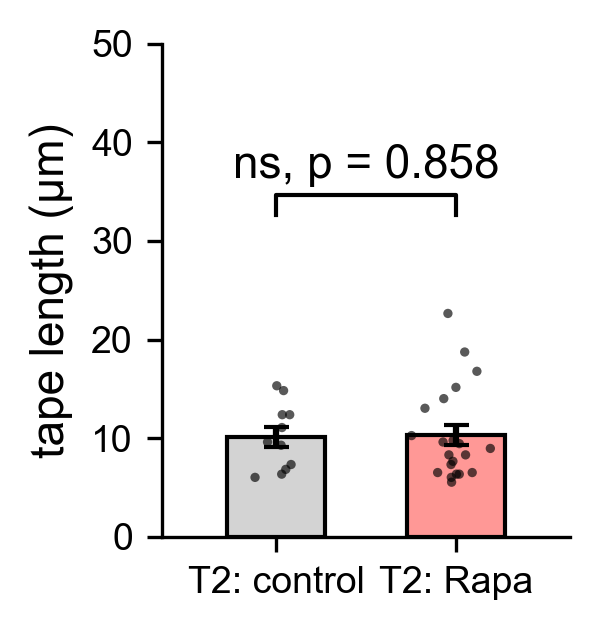

Mann–Whitney U statistic = 167.000
p value = 0.8129


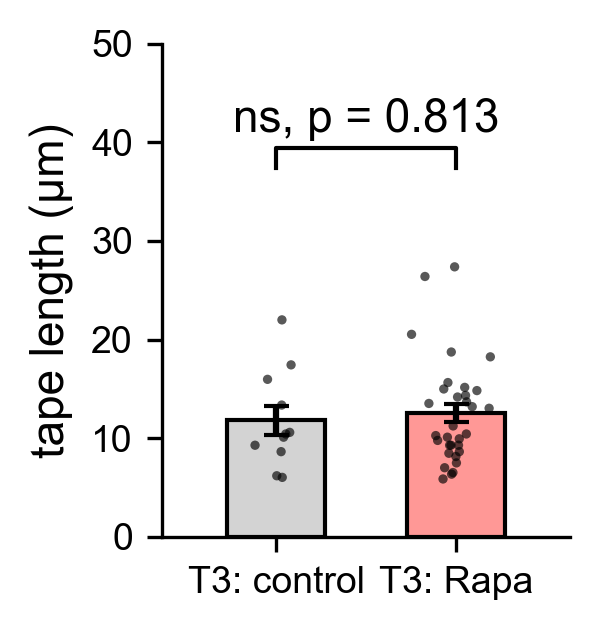

Mann–Whitney U statistic = 143.500
p value = 0.7384


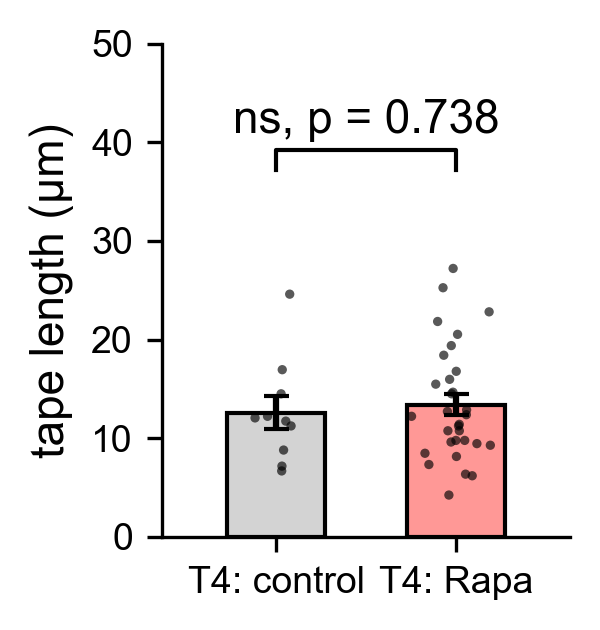

Mann–Whitney U statistic = 181.500
p value = 0.3012


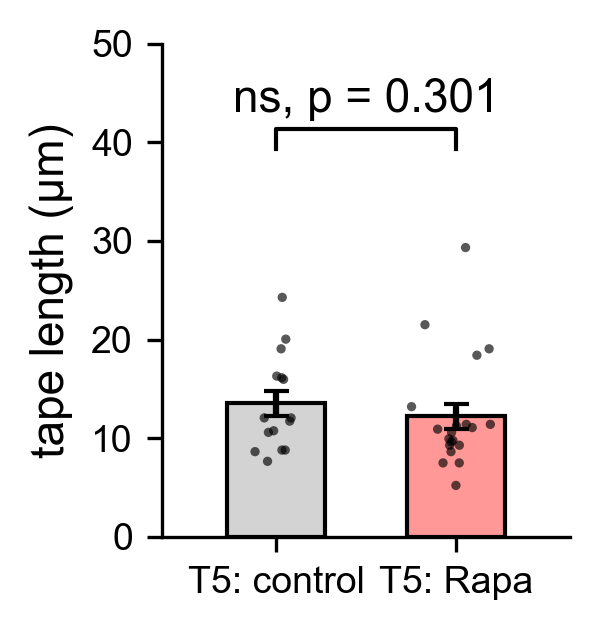

Mann–Whitney U statistic = 175.500
p value = 0.512


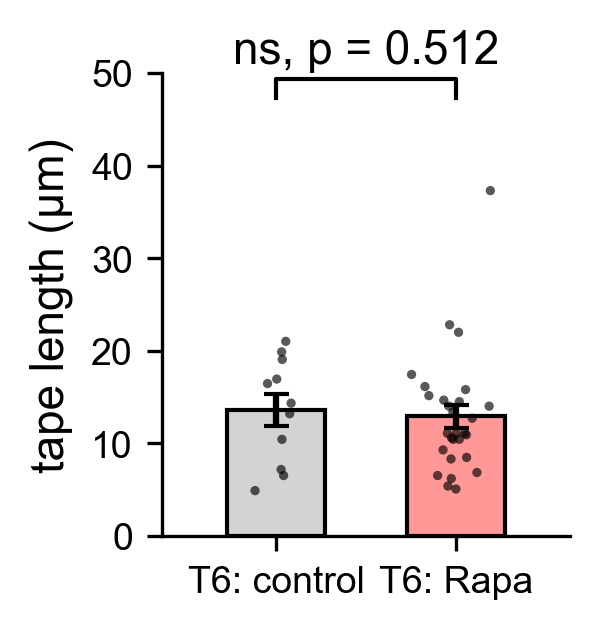

Mann–Whitney U statistic = 80.000
p value = 0.6542


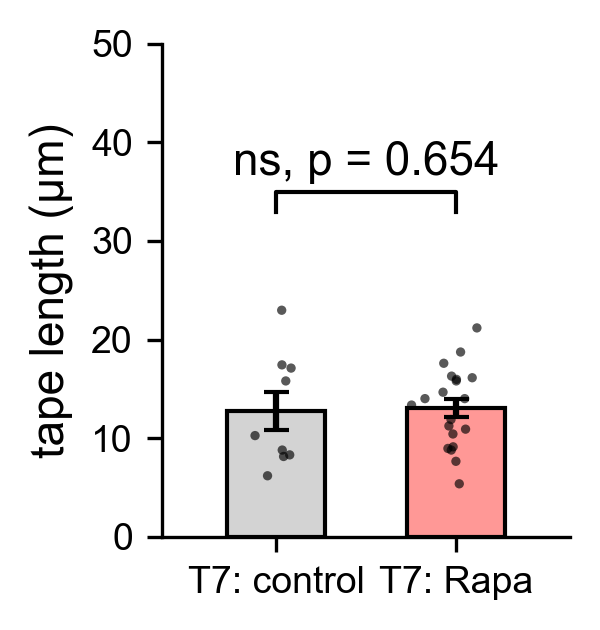

Mann–Whitney U statistic = 364.500
p value = 0.6274


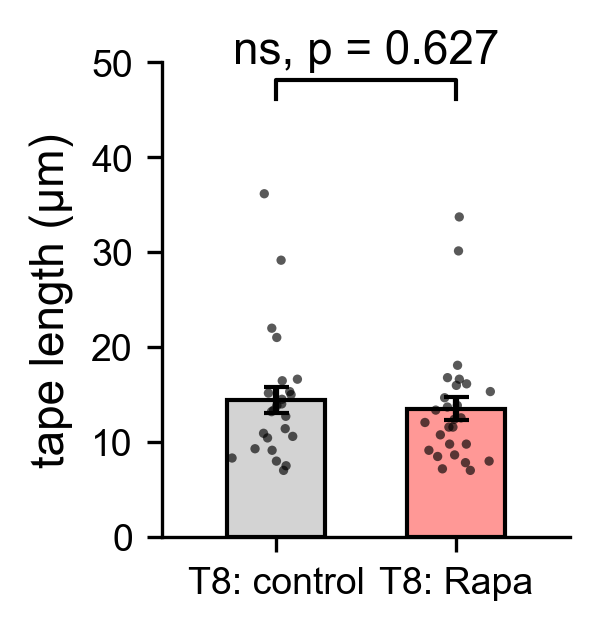

In [9]:


for i in range (len(drug_lengths)):

    stat, p = mannwhitney_bar_with_dots(
    control_lengths[i],
    drug_lengths[i],
    labels=(f"T{i+1}: control", f"T{i+1}: Rapa"),
    ylabel="tape length (μm)",
    xpos=(0, 0.55),
    bar_width=0.30,
    figsize=(2.1, 2.2),
    bracket_offset=10,
    dot_size=5,
    jitter_strength=0.05,
)

# Figure S4D

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def mannwhitney_bar_with_dots(
    list1,
    list2,
    labels=("Control", "Drug"),
    ylabel="Value",
    figsize=(2.0, 3.0),
    bar_width=0.32,
    xpos=(0, 0.58),   
    ylim=(0, 50),
    bracket_height=2,
    bracket_offset=2,
    dot_size=14,
    jitter_strength=0.045,
):
    x1 = np.asarray(list1, dtype=float)
    x2 = np.asarray(list2, dtype=float)

    x1 = x1[np.isfinite(x1)]
    x2 = x2[np.isfinite(x2)]

    stat, p = mannwhitneyu(x1, x2, alternative="two-sided")

    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4g}")

    means = [np.mean(x1), np.mean(x2)]
    sems = [
        np.std(x1, ddof=1) / np.sqrt(len(x1)),
        np.std(x2, ddof=1) / np.sqrt(len(x2))
    ]

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    bar_colors = ["#F8C3C2", "#FF9896"]

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=3,
        color=bar_colors,
        edgecolor="black",
        linewidth=1,
        width=bar_width,
        zorder=1
    )

    rng = np.random.default_rng(1)
    jitter1 = rng.normal(0, jitter_strength, size=len(x1))
    jitter2 = rng.normal(0, jitter_strength, size=len(x2))

    ax.scatter(
        np.full(len(x1), xpos[0]) + jitter1,
        x1,
        s=dot_size,
        color="black",
        alpha=0.65,
        edgecolors="none",
        zorder=2
    )

    ax.scatter(
        np.full(len(x2), xpos[1]) + jitter2,
        x2,
        s=dot_size,
        color="black",
        alpha=0.65,
        edgecolors="none",
        zorder=2
    )

    if p < 0.001:
        p_text = "***"
    elif p < 0.01:
        p_text = "**"
    elif p < 0.05:
        p_text = "*"
    else:
        p_text = "ns"

    y_max_data = max(
        np.max(x1),
        np.max(x2),
        means[0] + sems[0],
        means[1] + sems[1]
    )

    y = y_max_data + bracket_offset
    h = bracket_height

    ax.plot(
        [xpos[0], xpos[0], xpos[1], xpos[1]],
        [y, y + h, y + h, y],
        color="black",
        linewidth=1
    )

    ax.text(
        np.mean(xpos),
        y + h + 0.8,
        f"{p_text}",
        ha="center",
        va="bottom",
        fontsize=16
    )

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=9)

    ax.set_ylim(ylim)

    ax.set_xlim(xpos[0] - 0.35, xpos[1] + 0.35)

    plt.tight_layout()
    plt.show()

    return stat, p

Mann–Whitney U statistic = 257.000
p value = 0.005201


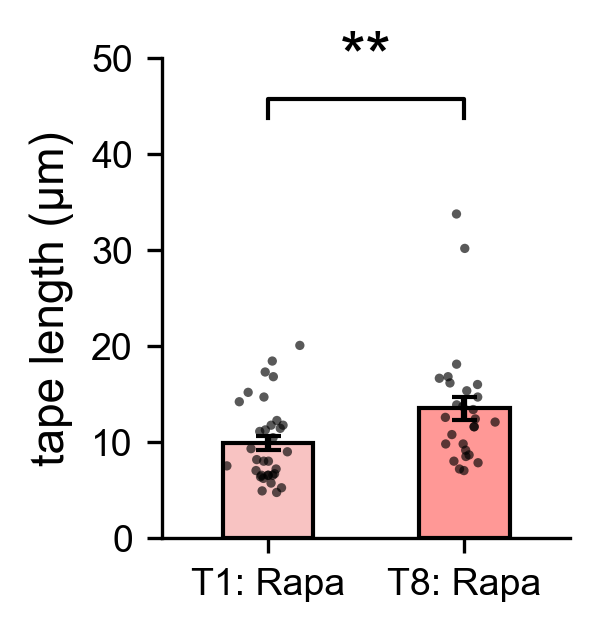

In [13]:
stat, p = mannwhitney_bar_with_dots(
    drug_lengths[0],
    drug_lengths[7],
    labels=(f"T{1}: Rapa", f"T{8}: Rapa"),
    ylabel="tape length (μm)",
    xpos=(0, 0.65),
    bar_width=0.30,
    figsize=(2.1, 2.2),
    bracket_offset=10,
    dot_size=5,
    jitter_strength=0.05,
)

# Figure S4C

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


def mannwhitney_bar_with_dots(
    list1,
    list2,
    labels=("Control", "Drug"),
    ylabel="Value",
    figsize=(2.0, 3.0),
    bar_width=0.32,
    xpos=(0, 0.58),   
    ylim=(0, 50),
    bracket_height=2,
    bracket_offset=2,
    dot_size=14,
    jitter_strength=0.045,
):
    x1 = np.asarray(list1, dtype=float)
    x2 = np.asarray(list2, dtype=float)

    x1 = x1[np.isfinite(x1)]
    x2 = x2[np.isfinite(x2)]

    stat, p = mannwhitneyu(x1, x2, alternative="two-sided")

    print(f"Mann–Whitney U statistic = {stat:.3f}")
    print(f"p value = {p:.4g}")

    means = [np.mean(x1), np.mean(x2)]
    sems = [
        np.std(x1, ddof=1) / np.sqrt(len(x1)),
        np.std(x2, ddof=1) / np.sqrt(len(x2))
    ]

    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    # bar_colors = ["#F8C3C2", "#FF9896"]
    bar_colors = ["lightgrey", "#656565"]

    ax.bar(
        xpos,
        means,
        yerr=sems,
        capsize=3,
        color=bar_colors,
        edgecolor="black",
        linewidth=1,
        width=bar_width,
        zorder=1
    )

    rng = np.random.default_rng(1)
    jitter1 = rng.normal(0, jitter_strength, size=len(x1))
    jitter2 = rng.normal(0, jitter_strength, size=len(x2))

    ax.scatter(
        np.full(len(x1), xpos[0]) + jitter1,
        x1,
        s=dot_size,
        color="black",
        alpha=0.65,
        edgecolors="none",
        zorder=2
    )

    ax.scatter(
        np.full(len(x2), xpos[1]) + jitter2,
        x2,
        s=dot_size,
        color="black",
        alpha=0.65,
        edgecolors="none",
        zorder=2
    )

    if p < 0.001:
        p_text = "***"
    elif p < 0.01:
        p_text = "**"
    elif p < 0.05:
        p_text = "*"
    else:
        p_text = "ns"

    y_max_data = max(
        np.max(x1),
        np.max(x2),
        means[0] + sems[0],
        means[1] + sems[1]
    )

    y = y_max_data + bracket_offset
    h = bracket_height

    ax.plot(
        [xpos[0], xpos[0], xpos[1], xpos[1]],
        [y, y + h, y + h, y],
        color="black",
        linewidth=1
    )

    ax.text(
        np.mean(xpos),
        y + h + 0.8,
        f"{p_text}",
        ha="center",
        va="bottom",
        fontsize=16
    )

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=9)

    ax.set_ylim(ylim)

    ax.set_xlim(xpos[0] - 0.35, xpos[1] + 0.35)

    plt.tight_layout()
    plt.show()

    return stat, p

Mann–Whitney U statistic = 80.000
p value = 0.005653


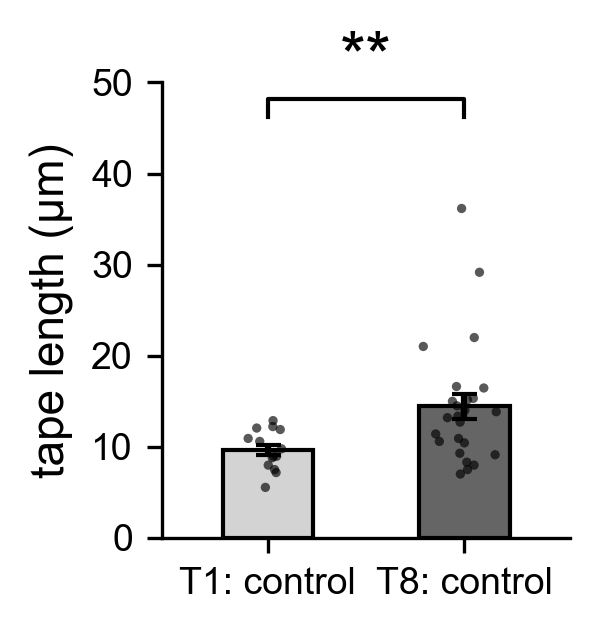

In [15]:
stat, p = mannwhitney_bar_with_dots(
    control_lengths[0],
    control_lengths[7],
    labels=(f"T{1}: control", f"T{8}: control"),
    ylabel="tape length (μm)",
    xpos=(0, 0.65),
    bar_width=0.30,
    figsize=(2.1, 2.2),
    bracket_offset=10,
    dot_size=5,
    jitter_strength=0.05,
)